# Pan–Tompkins R peaks and P/T boundaries

This notebook detects R peaks with the Pan–Tompkins processing chain, evaluates them against the QT Database `atr` beat annotations, then estimates P and T onset/offset locations using wavelet delineation anchored to those detected R peaks. P/T boundaries are estimates: inspect the overlay and treat them as unsuitable for diagnosis without clinical review.

In [8]:
# Run once in the notebook kernel if these packages are not already installed.
%pip install -q wfdb scipy pandas matplotlib neurokit2

Note: you may need to restart the kernel to use updated packages.


In [9]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, sosfiltfilt, find_peaks
import wfdb
import neurokit2 as nk

# This is relative to the repository, so the notebook works on another machine too.
REPO_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'PQRST_mapping' else Path.cwd().resolve()
DATA_DIR = REPO_ROOT / 'physionet.org/files/qtdb/1.0.0'
RECORD = 'sel100'              # Change to another QTDB record if required.
LEAD = 0                       # MLII for sel100
record_path = str(DATA_DIR / RECORD)
assert (DATA_DIR / f'{RECORD}.hea').exists(), f'Missing record: {record_path}'

record = wfdb.rdrecord(record_path)
ecg = record.p_signal[:, LEAD].astype(float)
fs = float(record.fs)
print(f'Record: {RECORD} | lead: {record.sig_name[LEAD]} | fs: {fs:g} Hz | samples: {len(ecg)}')

Record: sel100 | lead: MLII | fs: 250 Hz | samples: 225000


In [10]:
def pan_tompkins(ecg, fs, lowcut=5.0, highcut=18.0):
    """Pan–Tompkins: band-pass -> derivative -> square -> moving integration."""
    nyquist = fs / 2
    sos = butter(3, [lowcut / nyquist, highcut / nyquist], btype='bandpass', output='sos')
    bandpassed = sosfiltfilt(sos, ecg)

    # Five-point derivative used by the original method, scaled for the sampling rate.
    derivative = np.convolve(bandpassed, np.array([-1, -2, 0, 2, 1]) * fs / 8, mode='same')
    squared = derivative ** 2
    integration_window = max(1, round(0.150 * fs))
    integrated = np.convolve(squared, np.ones(integration_window) / integration_window, mode='same')

    # Adaptive signal/noise thresholds on MWI local maxima.
    candidates, _ = find_peaks(integrated, distance=max(1, round(0.20 * fs)))
    bootstrap = candidates[candidates < min(len(ecg), round(2 * fs))]
    if len(bootstrap) == 0:
        bootstrap = candidates
    spki = np.percentile(integrated[bootstrap], 90) if len(bootstrap) else np.max(integrated)
    npki = np.percentile(integrated[bootstrap], 25) if len(bootstrap) else 0.0
    qrs = []
    for peak in candidates:
        threshold_i1 = npki + 0.25 * (spki - npki)
        if integrated[peak] >= threshold_i1:
            qrs.append(peak)
            spki = 0.125 * integrated[peak] + 0.875 * spki
        else:
            npki = 0.125 * integrated[peak] + 0.875 * npki

    # The integration maximum is delayed and broad; recenter it on the ECG R maximum.
    search = round(0.10 * fs)
    refined = []
    for peak in qrs:
        left, right = max(0, peak - search), min(len(ecg), peak + search + 1)
        refined.append(left + np.argmax(ecg[left:right]))
    refined = np.asarray(refined, dtype=int)
    return bandpassed, derivative, squared, integrated, np.unique(refined)

bandpassed, derivative, squared, integrated, r_peaks = pan_tompkins(ecg, fs)
print(f'Pan–Tompkins detected {len(r_peaks)} R peaks ({len(r_peaks) / (len(ecg) / fs / 60):.1f} bpm).')

Pan–Tompkins detected 1134 R peaks (75.6 bpm).


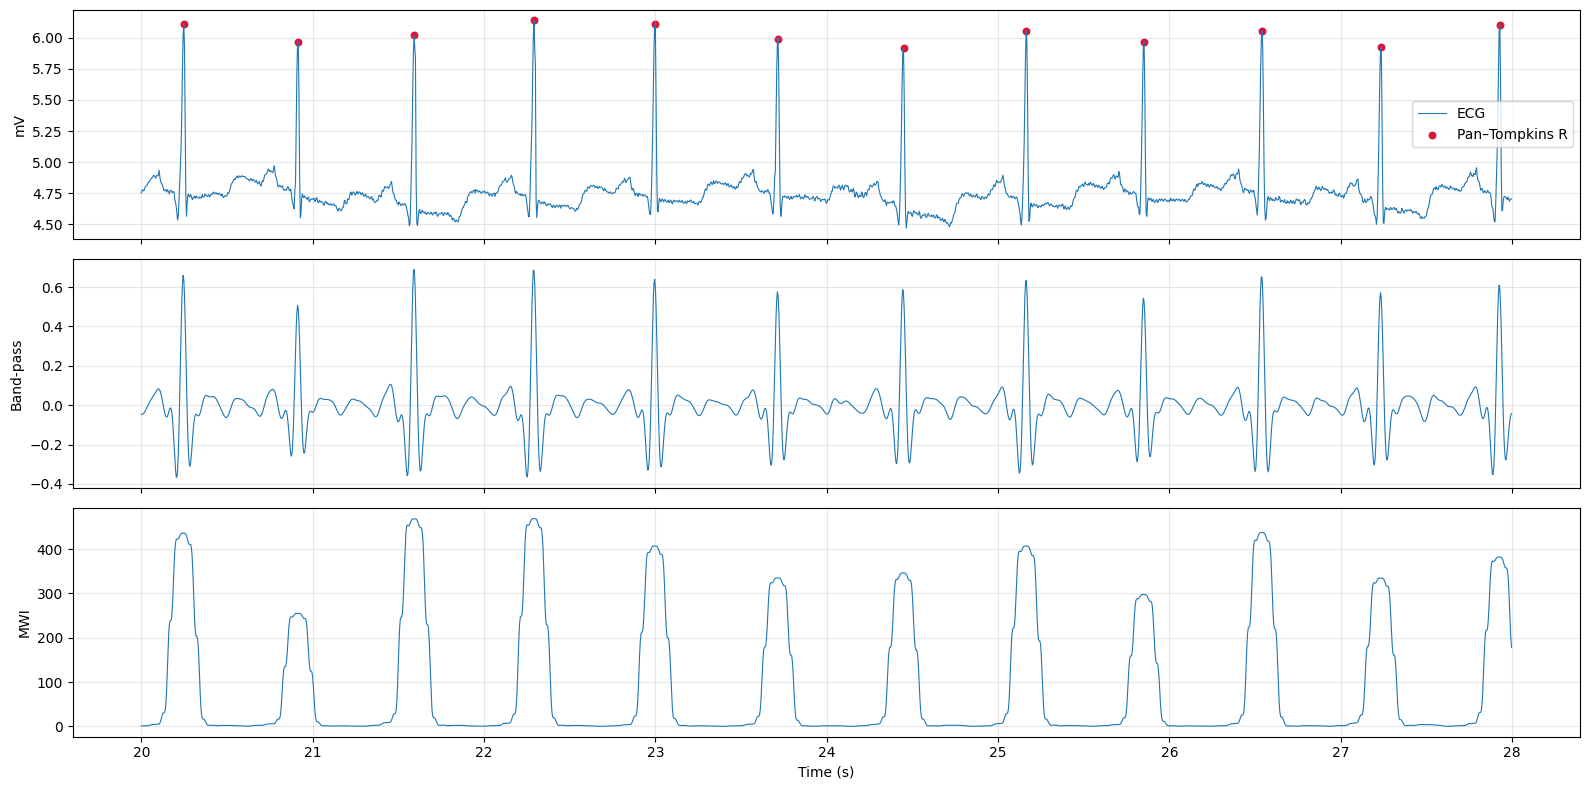

In [11]:
# Inspect each Pan–Tompkins stage over a short segment.
start_s, duration_s = 20, 8
a, b = int(start_s * fs), int((start_s + duration_s) * fs)
x = np.arange(a, b) / fs
fig, axes = plt.subplots(3, 1, figsize=(16, 8), sharex=True)
axes[0].plot(x, ecg[a:b], lw=0.8, label='ECG')
shown_r = r_peaks[(r_peaks >= a) & (r_peaks < b)]
axes[0].scatter(shown_r / fs, ecg[shown_r], color='crimson', s=22, label='Pan–Tompkins R')
axes[0].legend(); axes[0].set_ylabel('mV')
axes[1].plot(x, bandpassed[a:b], lw=0.8); axes[1].set_ylabel('Band-pass')
axes[2].plot(x, integrated[a:b], lw=0.8); axes[2].set_ylabel('MWI'); axes[2].set_xlabel('Time (s)')
for ax in axes: ax.grid(alpha=0.3)
plt.tight_layout()

In [12]:
# QTDB atr is an independent beat-level reference annotation for R-peak evaluation.
# Each reference/detection pair can be used once, preventing double-counted true positives.
ann = wfdb.rdann(record_path, 'atr')
BEAT_SYMBOLS = {'N', 'L', 'R', 'A', 'a', 'J', 'S', 'V', 'F', 'e', 'j', '/', 'f', 'Q', '?'}
true_r = np.asarray([sample for sample, symbol in zip(ann.sample, ann.symbol) if symbol in BEAT_SYMBOLS], dtype=int)

def match_peaks(reference, detected, tolerance_samples):
    matches, used = [], set()
    for ref in reference:
        nearby = np.where(np.abs(detected - ref) <= tolerance_samples)[0]
        nearby = [i for i in nearby if i not in used]
        if nearby:
            i = min(nearby, key=lambda j: abs(detected[j] - ref))
            used.add(i); matches.append((ref, detected[i]))
    return np.asarray(matches, dtype=int).reshape(-1, 2)

tolerance_ms = 75
matches = match_peaks(true_r, r_peaks, round(tolerance_ms * fs / 1000))
tp = len(matches); fp = len(r_peaks) - tp; fn = len(true_r) - tp
precision = tp / (tp + fp) if tp + fp else np.nan
recall = tp / (tp + fn) if tp + fn else np.nan
f1 = 2 * precision * recall / (precision + recall) if precision + recall else np.nan
timing_mae_ms = np.mean(np.abs(matches[:, 1] - matches[:, 0])) / fs * 1000 if tp else np.nan
metrics = pd.Series({'reference beats': len(true_r), 'detected beats': len(r_peaks), 'TP': tp, 'FP': fp, 'FN': fn,
                     'precision': precision, 'recall (sensitivity)': recall, 'F1': f1, 'mean |timing error| (ms)': timing_mae_ms})
display(metrics.to_frame('value'))
print('Efficacy check:', 'good alignment on this record' if f1 >= 0.99 else 'inspect false positives/negatives before using downstream boundaries.')

,value
reference beats,1134.000000
detected beats,1134.000000
TP,1134.000000
FP,0.000000
FN,0.000000
precision,1.000000
recall (sensitivity),1.000000
F1,1.000000
mean |timing error| (ms),1.132275


Efficacy check: good alignment on this record


In [13]:
# Delineate P and T waves using the detected (not reference) R peaks.
# DWT is more stable for onset/offset landmarks than a fixed time-from-R rule.
_, waves = nk.ecg_delineate(ecg, rpeaks={'ECG_R_Peaks': r_peaks}, sampling_rate=fs, method='dwt', show=False)

def landmark_array(name):
    values = np.asarray(waves.get(name, []), dtype=float)
    if len(values) < len(r_peaks):
        values = np.pad(values, (0, len(r_peaks) - len(values)), constant_values=np.nan)
    return values[:len(r_peaks)]

wave_table = pd.DataFrame({
    'beat': np.arange(len(r_peaks)), 'r_peak': r_peaks, 'r_peak_s': r_peaks / fs,
    'p_onset': landmark_array('ECG_P_Onsets'), 'p_offset': landmark_array('ECG_P_Offsets'),
    't_onset': landmark_array('ECG_T_Onsets'), 't_offset': landmark_array('ECG_T_Offsets'),
})
for col in ['p_onset', 'p_offset', 't_onset', 't_offset']:
    wave_table[col] = wave_table[col].round().astype('Int64')
    wave_table[f'{col}_s'] = wave_table[col] / fs

display(wave_table.head(12))
print('Missing landmark counts:')
display(wave_table[['p_onset', 'p_offset', 't_onset', 't_offset']].isna().sum().to_frame('missing'))

,beat,r_peak,r_peak_s,p_onset,p_offset,t_onset,t_offset,p_onset_s,p_offset_s,t_onset_s,t_offset_s
0,0,143,0.572,84,105,160,168,0.336,0.42,0.64,0.672
1,1,347,1.388,306,318,<NA>,<NA>,1.224,1.272,<NA>,<NA>
2,2,537,2.148,494,506,585,590,1.976,2.024,2.34,2.36
3,3,720,2.880,674,681,752,760,2.696,2.724,3.008,3.04
4,4,910,3.640,855,869,957,972,3.42,3.476,3.828,3.888
5,5,1098,4.392,1039,1060,1127,1131,4.156,4.24,4.508,4.524
6,6,1296,5.184,1255,1265,1315,1318,5.02,5.06,5.26,5.272
7,7,1501,6.004,1458,1469,1548,1557,5.832,5.876,6.192,6.228
8,8,1697,6.788,1655,1668,1731,1736,6.62,6.672,6.924,6.944
9,9,1890,7.560,1848,1859,1969,1973,7.392,7.436,7.876,7.892


Missing landmark counts:


,missing
p_onset,0
p_offset,0
t_onset,24
t_offset,24


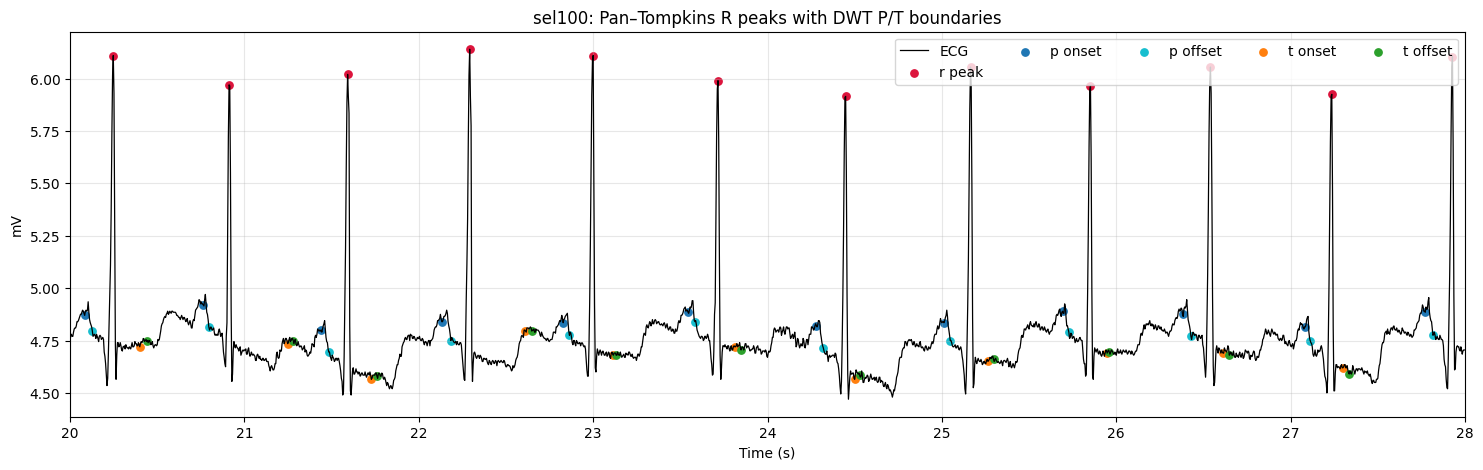

In [14]:
# Visual verification of the landmarks. Use a clean, representative 8-second window.
start_s, duration_s = 20, 8
a, b = int(start_s * fs), int((start_s + duration_s) * fs)
subset = wave_table[(wave_table.r_peak >= a) & (wave_table.r_peak < b)]
plt.figure(figsize=(18, 5))
plt.plot(np.arange(a, b) / fs, ecg[a:b], color='black', lw=0.9, label='ECG')
colors = {'r_peak': 'crimson', 'p_onset': 'tab:blue', 'p_offset': 'tab:cyan', 't_onset': 'tab:orange', 't_offset': 'tab:green'}
for column, color in colors.items():
    samples = subset[column].dropna().astype(int).to_numpy()
    if len(samples): plt.scatter(samples / fs, ecg[samples], s=28, color=color, label=column.replace('_', ' '))
plt.xlim(start_s, start_s + duration_s); plt.xlabel('Time (s)'); plt.ylabel('mV')
plt.title(f'{RECORD}: Pan–Tompkins R peaks with DWT P/T boundaries')
plt.grid(alpha=0.3); plt.legend(ncol=5, loc='upper right'); plt.show()

In [15]:
# Ground-truth QTDB statistics. Do this before training a regression model.
# pu0: waveform onset '(' / peak (p, N, t) / offset ')'.
def parse_pu_boundaries(annotation):
    onset, kind, waves = None, None, []
    for sample, symbol in zip(annotation.sample, annotation.symbol):
        if symbol == '(':
            onset, kind = sample, None
        elif symbol in {'p', 't'} and onset is not None:
            kind = symbol
        elif symbol == ')':
            if onset is not None and kind is not None and sample > onset:
                waves.append((kind, onset, sample))
            onset, kind = None, None
    return waves

def qtdb_offset_rows(data_dir):
    rows, skipped = [], []
    for dat_file in sorted(data_dir.glob('*.dat')):
        name, path = dat_file.stem, str(dat_file.with_suffix(''))
        try:
            header = wfdb.rdheader(path)
            atr, pu0 = wfdb.rdann(path, 'atr'), wfdb.rdann(path, 'pu0')
        except Exception as error:
            skipped.append((name, str(error))); continue
        r_peaks_ref = np.asarray([s for s, sym in zip(atr.sample, atr.symbol) if sym in BEAT_SYMBOLS], dtype=int)
        waves = parse_pu_boundaries(pu0)
        p_waves = [(start, end) for kind, start, end in waves if kind == 'p']
        t_waves = [(start, end) for kind, start, end in waves if kind == 't']
        for r in r_peaks_ref:
            p = [w for w in p_waves if 0 < r - w[1] <= 0.45 * header.fs]
            t = [w for w in t_waves if 0 <= w[0] - r <= 0.80 * header.fs]
            if p and t:
                p_on, p_off = max(p, key=lambda w: w[1])
                t_on, t_off = min(t, key=lambda w: w[0])
                rows.append({'record': name, 'r_peak': r,
                    'p_onset_minus_r_ms': (p_on-r) / header.fs * 1000,
                    'p_offset_minus_r_ms': (p_off-r) / header.fs * 1000,
                    't_onset_minus_r_ms': (t_on-r) / header.fs * 1000,
                    't_offset_minus_r_ms': (t_off-r) / header.fs * 1000})
    return pd.DataFrame(rows), skipped

qtdb_offsets, skipped_records = qtdb_offset_rows(DATA_DIR)
print(f'Usable annotated beats: {len(qtdb_offsets)} | skipped records: {len(skipped_records)}')
if qtdb_offsets.empty: raise RuntimeError('No usable pu0/atr annotation pairs found.')

Usable annotated beats: 77234 | skipped records: 23


,count,mean,median,std,min,max,2.5%,97.5%
p_onset_minus_r_ms,77234.0,-194.66,-192.0,41.03,-560.0,-60.0,-268.0,-120.0
p_offset_minus_r_ms,77234.0,-97.55,-92.0,36.83,-448.0,-4.0,-180.0,-36.0
t_onset_minus_r_ms,77234.0,185.82,180.0,70.30,0.0,800.0,88.0,308.0
t_offset_minus_r_ms,77234.0,382.88,372.0,88.93,172.0,1260.0,252.0,668.0


p_onset_minus_r_ms: search -268.0 to -120.0 ms from R
p_offset_minus_r_ms: search -180.0 to -36.0 ms from R
t_onset_minus_r_ms: search 88.0 to 308.0 ms from R
t_offset_minus_r_ms: search 252.0 to 668.0 ms from R


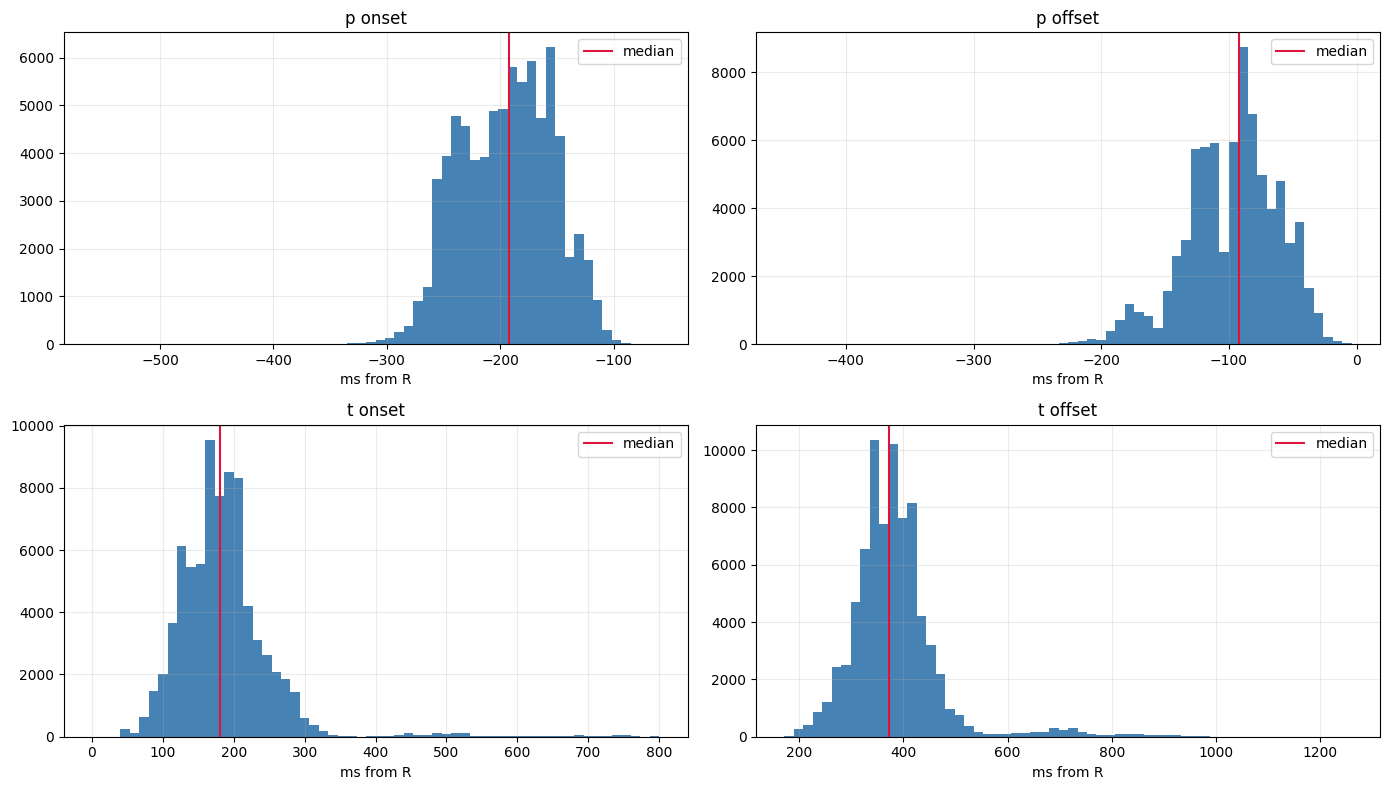

In [16]:
offset_columns = ['p_onset_minus_r_ms', 'p_offset_minus_r_ms', 't_onset_minus_r_ms', 't_offset_minus_r_ms']
summary = qtdb_offsets[offset_columns].agg(['count', 'mean', 'median', 'std', 'min', 'max']).T
intervals = qtdb_offsets[offset_columns].quantile([0.025, 0.975]).T.rename(columns={0.025: '2.5%', 0.975: '97.5%'})
summary = summary.join(intervals)
display(summary.round(2))
for landmark, row in summary.iterrows():
    print(f'{landmark}: search {row["2.5%"]:.1f} to {row["97.5%"]:.1f} ms from R')

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, column in zip(axes.flat, offset_columns):
    ax.hist(qtdb_offsets[column], bins=60, color='steelblue')
    ax.axvline(qtdb_offsets[column].median(), color='crimson', label='median')
    ax.set_title(column.replace('_minus_r_ms', '').replace('_', ' '))
    ax.set_xlabel('ms from R'); ax.grid(alpha=0.25); ax.legend()
plt.tight_layout()

## Next model (not trained here)

Input: R-centred ECG beat. Output: `[P onset − R, P offset − R, T onset − R, T offset − R]` in ms. Loss: Smooth L1 / Huber. Use shown 95% ranges as search bounds. Stop here: no pipeline code, no training.